In [1]:
import sys
sys.path.insert(0, '/Users/seb/Desktop/Seminararbeit/RobynData/Do-PFN')

import torch
import numpy as np
import pandas as pd
import requests
import pyreadr
import warnings
import matplotlib.pyplot as plt
from copy import deepcopy
from sklearn.preprocessing import MaxAbsScaler, StandardScaler

warnings.filterwarnings("ignore")

from scripts.transformer_prediction_interface.base import DoPFNRegressor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print("All imports successful!")

Device: cpu
All imports successful!


In [2]:
import requests
import pyreadr

url = "https://github.com/facebookexperimental/Robyn/raw/main/R/data/dt_simulated_weekly.RData"
response = requests.get(url)
with open("dt_simulated_weekly.RData", "wb") as f:
    f.write(response.content)

result = pyreadr.read_r("dt_simulated_weekly.RData")
df = result["dt_simulated_weekly"]

df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

target       = "revenue"
media_cols   = ["tv_S", "ooh_S", "print_S", "facebook_S", "search_S"]
control_cols = ["competitor_sales_B", "newsletter"]

split_idx = int(len(df) * 0.8)
train_df  = df.iloc[:split_idx].copy()
test_df   = df.iloc[split_idx:].copy()

print(f"Total: {len(df)} | Train: {len(train_df)} | Test: {len(test_df)}")
df[["DATE", "revenue"] + media_cols].head()

Total: 208 | Train: 166 | Test: 42


,DATE,revenue,tv_S,ooh_S,print_S,facebook_S,search_S
0,2015-11-23,2.754372e+06,22358.346667,0.0,12728.488889,7607.132915,0.000000
1,2015-11-30,2.584277e+06,28613.453333,0.0,0.000000,1141.952450,4133.333333
2,2015-12-07,2.547387e+06,0.000000,132278.4,453.866667,4256.375378,3786.666667
3,2015-12-14,2.875220e+06,83450.306667,0.0,17680.000000,2800.490677,4253.333333
4,2015-12-21,2.215953e+06,0.000000,277336.0,0.000000,689.582605,3613.333333


In [3]:
def geometric_adstock(x: np.ndarray, alpha: float, l_max: int = 8) -> np.ndarray:
    """
    Geometric adstock transformation.
    Each week's value is a weighted sum of current and past spend,
    with weights decaying geometrically by factor alpha.
    """
    x_adstocked = np.zeros_like(x, dtype=float)
    for t in range(len(x)):
        for lag in range(min(l_max, t + 1)):
            x_adstocked[t] += (alpha ** lag) * x[t - lag]
    return x_adstocked

# Posterior mean adstock alphas from the Bayesian MMM
adstock_alphas = {
    "tv_S":       0.241,
    "ooh_S":      0.572,
    "print_S":    0.428,
    "facebook_S": 0.540,
    "search_S":   0.558
}

# Apply to full dataset before splitting
df_adstock = df.copy()
for col, alpha in adstock_alphas.items():
    df_adstock[col + "_adstock"] = geometric_adstock(df[col].values, alpha=alpha)

adstock_cols  = [col + "_adstock" for col in media_cols]
train_adstock = df_adstock.iloc[:split_idx].copy()
test_adstock  = df_adstock.iloc[split_idx:].copy()

print("Adstock transformation complete.")
df_adstock[["DATE"] + adstock_cols].head()

Adstock transformation complete.


,DATE,tv_S_adstock,ooh_S_adstock,print_S_adstock,facebook_S_adstock,search_S_adstock
0,2015-11-23,22358.346667,0.000000,12728.488889,7607.132915,0.000000
1,2015-11-30,34001.814880,0.000000,5447.793244,5249.804224,4133.333333
2,2015-12-07,8194.437386,132278.400000,2785.522175,7091.269659,6093.066667
3,2015-12-14,85425.166077,75663.244800,18872.203491,6629.776293,7653.264533
4,2015-12-21,20587.465024,320615.376026,8077.303094,4269.661803,7883.854943


In [4]:
def scale_data(X_train, X_test, m_cols, c_cols):
    """Scale media cols with MaxAbsScaler, control cols with StandardScaler.
    Both scalers are fitted on train only to prevent data leakage."""
    media_scaler   = MaxAbsScaler()
    control_scaler = StandardScaler()

    X_train = X_train.copy()
    X_test  = X_test.copy()

    X_train[m_cols] = media_scaler.fit_transform(X_train[m_cols])
    X_test[m_cols]  = media_scaler.transform(X_test[m_cols])

    X_train[c_cols] = control_scaler.fit_transform(X_train[c_cols])
    X_test[c_cols]  = control_scaler.transform(X_test[c_cols])

    return X_train, X_test


# Scale RAW feature sets
X_train_raw, X_test_raw = scale_data(
    train_df[media_cols + control_cols],
    test_df[media_cols + control_cols],
    media_cols, control_cols
)

# Scale ADSTOCK feature sets
X_train_ads, X_test_ads = scale_data(
    train_adstock[adstock_cols + control_cols],
    test_adstock[adstock_cols + control_cols],
    adstock_cols, control_cols
)

# Target on original scale
y_train = train_df[target].values.astype(np.float32)
y_test  = test_df[target].values.astype(np.float32)

print("Scaling complete.")
print(f"X_train_raw shape: {X_train_raw.shape}")
print(f"X_train_ads shape: {X_train_ads.shape}")

Scaling complete.
X_train_raw shape: (166, 7)
X_train_ads shape: (166, 7)


In [8]:
results_raw = {}

for channel in media_cols:
    print(f"\nChannel: {channel}")

    other_cols     = [c for c in media_cols if c != channel]
    covariate_cols = other_cols + control_cols

    T_train = (train_df[channel].values > 0).astype(np.float32).reshape(-1, 1)
    T_test  = (test_df[channel].values > 0).astype(np.float32).reshape(-1, 1)

    X_cov_train = X_train_raw[covariate_cols].values.astype(np.float32)
    X_cov_test  = X_test_raw[covariate_cols].values.astype(np.float32)

    X_train_dopfn = np.hstack([T_train, X_cov_train])
    X_test_dopfn  = np.hstack([T_test,  X_cov_test])

    dopfn = DoPFNRegressor()
    dopfn.fit(X_train_dopfn, y_train)

    x_t1 = deepcopy(X_test_dopfn); x_t1[:, 0] = 1.0
    x_t0 = deepcopy(X_test_dopfn); x_t0[:, 0] = 0.0

    y_t1 = dopfn.predict_full(torch.tensor(x_t1))['mean']
    y_t0 = dopfn.predict_full(torch.tensor(x_t0))['mean']
    cate = np.array(y_t1) - np.array(y_t0)

    results_raw[channel] = cate
    print(f"  Mean CATE (Raw): {np.mean(cate):>12,.2f}")
    print(f"  Std  CATE (Raw): {np.std(cate):>12,.2f}")

print("\nDo-PFN Raw complete.")


Channel: tv_S


Running inference:   0%|          | 0/1 [00:00<?, ?batch/s]

Running inference: 100%|██████████| 1/1 [00:00<00:00,  3.29batch/s]


  Mean CATE (Raw):   156,391.06
  Std  CATE (Raw):    73,613.77

Channel: ooh_S


Running inference: 100%|██████████| 1/1 [00:00<00:00,  2.39batch/s]


...

  Mean CATE (Raw):   106,225.23
  Std  CATE (Raw):    51,268.92

Channel: facebook_S


Running inference: 100%|██████████| 1/1 [00:00<00:00,  2.04batch/s]


  Mean CATE (Raw):    48,446.39
  Std  CATE (Raw):    57,427.36

Channel: search_S


Running inference: 100%|██████████| 1/1 [00:00<00:00,  2.87batch/s]

  Mean CATE (Raw):   -50,704.51
  Std  CATE (Raw):    47,664.61

Do-PFN Raw complete.


In [9]:
results_ads = {}

for channel in media_cols:
    print(f"\nChannel: {channel}")

    ads_col        = channel + "_adstock"
    other_ads      = [c + "_adstock" for c in media_cols if c != channel]
    covariate_cols = other_ads + control_cols

    T_train_ads = (train_adstock[ads_col].values > 0).astype(np.float32).reshape(-1, 1)
    T_test_ads  = (test_adstock[ads_col].values > 0).astype(np.float32).reshape(-1, 1)

    X_cov_train = X_train_ads[covariate_cols].values.astype(np.float32)
    X_cov_test  = X_test_ads[covariate_cols].values.astype(np.float32)

    X_train_dopfn = np.hstack([T_train_ads, X_cov_train])
    X_test_dopfn  = np.hstack([T_test_ads,  X_cov_test])

    dopfn_ads = DoPFNRegressor()
    dopfn_ads.fit(X_train_dopfn, y_train)

    x_t1 = deepcopy(X_test_dopfn); x_t1[:, 0] = 1.0
    x_t0 = deepcopy(X_test_dopfn); x_t0[:, 0] = 0.0

    y_t1 = dopfn_ads.predict_full(torch.tensor(x_t1))['mean']
    y_t0 = dopfn_ads.predict_full(torch.tensor(x_t0))['mean']
    cate = np.array(y_t1) - np.array(y_t0)

    results_ads[channel] = cate
    print(f"  Mean CATE (Adstock): {np.mean(cate):>12,.2f}")
    print(f"  Std  CATE (Adstock): {np.std(cate):>12,.2f}")

print("\nDo-PFN Adstock complete.")


Channel: tv_S


Running inference: 100%|██████████| 1/1 [00:00<00:00,  2.95batch/s]


  Mean CATE (Adstock):   202,738.23
  Std  CATE (Adstock):   166,013.22

Channel: ooh_S


Running inference: 100%|██████████| 1/1 [00:00<00:00,  3.58batch/s]


  Mean CATE (Adstock):   -91,154.52
  Std  CATE (Adstock):    60,376.64

Channel: print_S


...

  Mean CATE (Adstock):   125,525.77
  Std  CATE (Adstock):   114,016.63

Channel: facebook_S


Running inference: 100%|██████████| 1/1 [00:00<00:00,  3.33batch/s]


  Mean CATE (Adstock):   -90,744.84
  Std  CATE (Adstock):    57,867.93

Channel: search_S


Running inference: 100%|██████████| 1/1 [00:00<00:00,  3.59batch/s]

  Mean CATE (Adstock):  -210,017.58
  Std  CATE (Adstock):    67,758.10

Do-PFN Adstock complete.


In [10]:
# Summary table
cate_summary = pd.DataFrame({
    "Mean CATE (Raw)":     {ch: np.mean(results_raw[ch]) for ch in media_cols},
    "Mean CATE (Adstock)": {ch: np.mean(results_ads[ch]) for ch in media_cols},
}).round(2)

print("=" * 60)
print("Mean CATE per Channel — Do-PFN")
print("=" * 60)
print(cate_summary.to_string())

# Sign agreement
sign_df = pd.DataFrame({
    "Bayesian MMM":    ["+"] * len(media_cols),
    "Do-PFN Raw":     ["+" if np.mean(results_raw[ch]) > 0 else "-" for ch in media_cols],
    "Do-PFN Adstock": ["+" if np.mean(results_ads[ch]) > 0 else "-" for ch in media_cols],
}, index=media_cols)

print("\n" + "=" * 60)
print("Sign Agreement with Bayesian MMM (all channels positive)")
print("=" * 60)
print(sign_df.to_string())

match_raw = sum(np.mean(results_raw[ch]) > 0 for ch in media_cols) / len(media_cols) * 100
match_ads = sum(np.mean(results_ads[ch]) > 0 for ch in media_cols) / len(media_cols) * 100
print(f"\nDo-PFN Raw     : {match_raw:.0f}% sign agreement")
print(f"Do-PFN Adstock : {match_ads:.0f}% sign agreement")
print(f"Bayesian MMM   : 100% (reference)")

Mean CATE per Channel — Do-PFN
            Mean CATE (Raw)  Mean CATE (Adstock)
tv_S          156391.062500        202738.234375
ooh_S          39993.671875        -91154.523438
print_S       106225.226562        125525.773438
facebook_S     48446.398438        -90744.843750
search_S      -50704.511719       -210017.578125

Sign Agreement with Bayesian MMM (all channels positive)
           Bayesian MMM Do-PFN Raw Do-PFN Adstock
tv_S                  +          +              +
ooh_S                 +          +              -
print_S               +          +              +
facebook_S            +          +              -
search_S              +          -              -

Do-PFN Raw     : 80% sign agreement
Do-PFN Adstock : 40% sign agreement
Bayesian MMM   : 100% (reference)


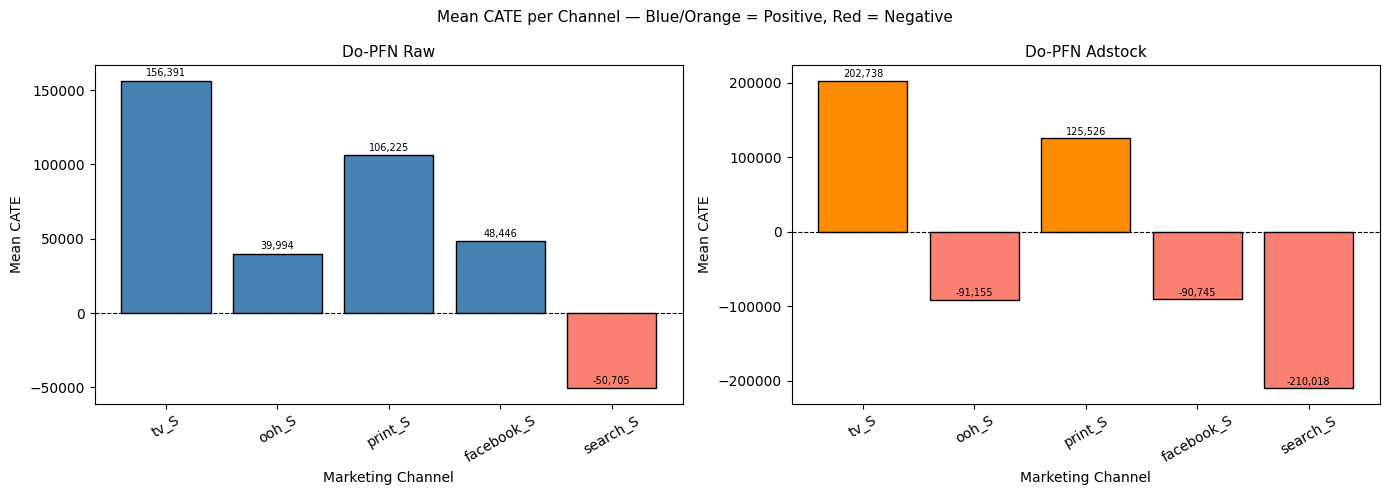

In [11]:
# Bar chart: Mean CATE per channel
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, results, color_pos, color_neg) in zip(axes, [
    ("Do-PFN Raw",     results_raw, "steelblue",  "salmon"),
    ("Do-PFN Adstock", results_ads, "darkorange", "salmon"),
]):
    means  = [np.mean(results[ch]) for ch in media_cols]
    colors = [color_pos if v > 0 else color_neg for v in means]

    bars = ax.bar(media_cols, means, color=colors, edgecolor="black")
    ax.axhline(y=0, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Marketing Channel")
    ax.set_ylabel("Mean CATE")
    ax.tick_params(axis="x", rotation=30)

    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(abs(v) for v in means) * 0.01,
                f"{val:,.0f}", ha="center", va="bottom", fontsize=7)

plt.suptitle("Mean CATE per Channel — Blue/Orange = Positive, Red = Negative", fontsize=11)
plt.tight_layout()
plt.show()

Full Model Comparison:
            Bayesian MMM ROAS  CausalPFN Raw  CausalPFN Adstock     Do-PFN Raw  Do-PFN Adstock
tv_S                     0.26      381131.03          908742.69  156391.062500   202738.234375
ooh_S                    0.10      -65830.89         -981255.31   39993.671875   -91154.523438
print_S                  0.08      -46365.78          725554.06  106225.226562   125525.773438
facebook_S               0.13       -3943.10         -354230.81   48446.398438   -90744.843750
search_S                 0.05     -158678.73        -1145777.88  -50704.511719  -210017.578125


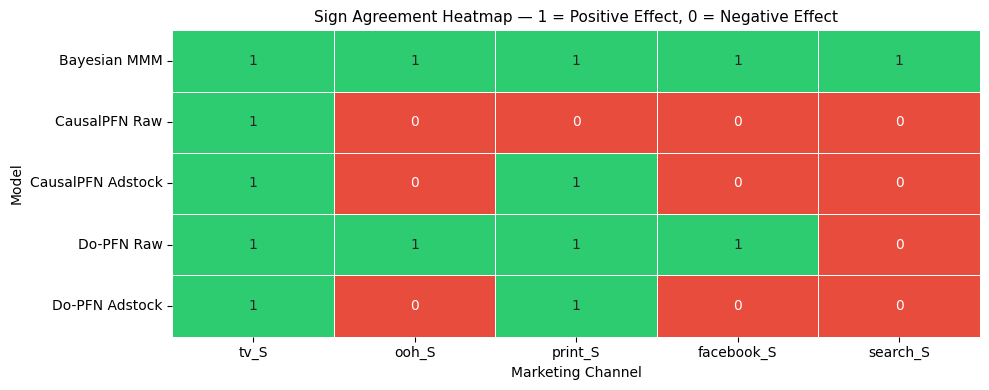

In [12]:
import seaborn as sns

# Full comparison table
causal_pfn_raw = {
    "tv_S": 381131.03, "ooh_S": -65830.89, "print_S": -46365.78,
    "facebook_S": -3943.10, "search_S": -158678.73
}
causal_pfn_ads = {
    "tv_S": 908742.69, "ooh_S": -981255.31, "print_S": 725554.06,
    "facebook_S": -354230.81, "search_S": -1145777.88
}

comparison = pd.DataFrame({
    "Bayesian MMM ROAS":    {"tv_S": 0.261, "ooh_S": 0.105, "print_S": 0.080,
                             "facebook_S": 0.126, "search_S": 0.048},
    "CausalPFN Raw":        causal_pfn_raw,
    "CausalPFN Adstock":    causal_pfn_ads,
    "Do-PFN Raw":           {ch: round(np.mean(results_raw[ch]), 2) for ch in media_cols},
    "Do-PFN Adstock":       {ch: round(np.mean(results_ads[ch]), 2) for ch in media_cols},
})

print("Full Model Comparison:")
print(comparison.round(2).to_string())

# Sign agreement heatmap
sign_matrix = pd.DataFrame({
    "Bayesian MMM":      {ch: 1 for ch in media_cols},
    "CausalPFN Raw":     {ch: 1 if causal_pfn_raw[ch] > 0 else 0 for ch in media_cols},
    "CausalPFN Adstock": {ch: 1 if causal_pfn_ads[ch] > 0 else 0 for ch in media_cols},
    "Do-PFN Raw":        {ch: 1 if np.mean(results_raw[ch]) > 0 else 0 for ch in media_cols},
    "Do-PFN Adstock":    {ch: 1 if np.mean(results_ads[ch]) > 0 else 0 for ch in media_cols},
})

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    sign_matrix.T,
    annot=True, fmt="d",
    cmap=["#e74c3c", "#2ecc71"],
    linewidths=0.5, linecolor="white",
    cbar=False, ax=ax,
    vmin=0, vmax=1
)
ax.set_title("Sign Agreement Heatmap — 1 = Positive Effect, 0 = Negative Effect", fontsize=11)
ax.set_xlabel("Marketing Channel")
ax.set_ylabel("Model")
plt.tight_layout()
plt.show()

Sign Agreement with Bayesian MMM (all channels +)
  TabPFN (raw)                : 5/5 (100%)
  TabPFN (adstock)            : 5/5 (100%)
  TabPFN (adstock+sat)        : 4/5 (80%)
  CausalPFN (raw)             : 1/5 (20%)
  CausalPFN (adstock)         : 2/5 (40%)
  Do-PFN (raw)                : 4/5 (80%)
  Do-PFN (adstock)            : 2/5 (40%)
  Bayesian MMM                : 5/5 (100%) — reference


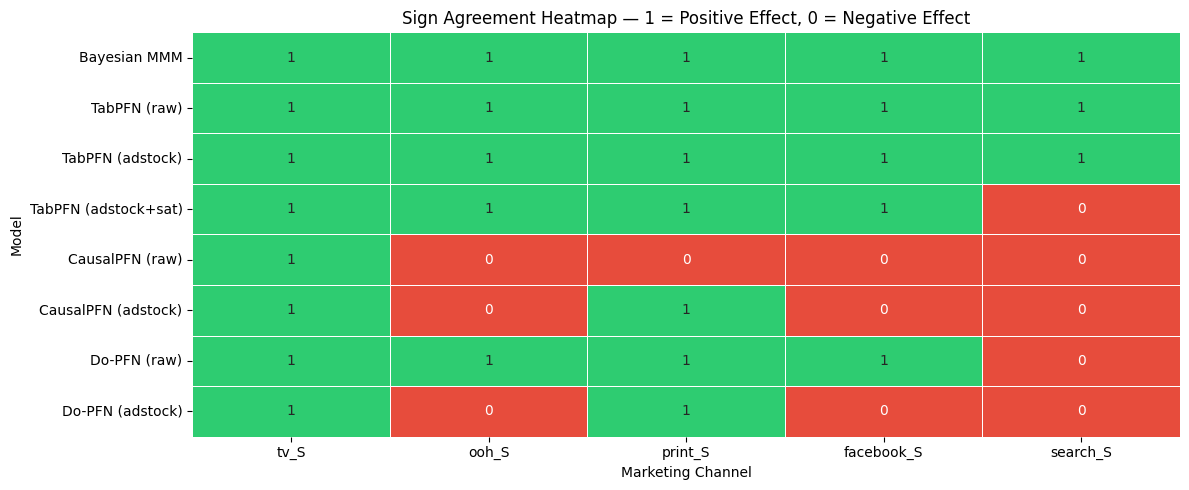


Forecast Accuracy — Test Period
Note: CausalPFN and Do-PFN estimate CATE, not revenue
                            MAE       RMSE  MAPE
Model                                           
Bayesian MMM          115134.78  218368.30  8.53
TabPFN (raw)           99086.33  214200.44  7.97
TabPFN (adstock)       94207.08  219723.31  7.41
TabPFN (adstock+sat)   97901.44  222992.17  7.68


In [13]:
import seaborn as sns

# ── Alle Ergebnisse aus allen Notebooks ──────────────────────────

# Bayesian MMM ROAS (Referenz)
bayesian_roas = {
    "tv_S": 0.261, "ooh_S": 0.105, "print_S": 0.080,
    "facebook_S": 0.126, "search_S": 0.048
}

# TabPFN ROAS (aus TabPFN Notebook)
tabpfn_raw_roas = {
    "tv_S": 4.550, "ooh_S": 0.148, "print_S": 5.582,
    "facebook_S": 8.098, "search_S": 0.429
}
tabpfn_ads_roas = {
    "tv_S": 5.654, "ooh_S": 0.320, "print_S": 10.959,
    "facebook_S": 15.657, "search_S": 0.118
}
tabpfn_sat_roas = {
    "tv_S": 9.239, "ooh_S": 0.402, "print_S": 14.975,
    "facebook_S": 16.511, "search_S": -5.104
}

# CausalPFN CATE (aus CausalPFN Notebook)
causal_raw = {
    "tv_S": 381131.03, "ooh_S": -65830.89, "print_S": -46365.78,
    "facebook_S": -3943.10, "search_S": -158678.73
}
causal_ads = {
    "tv_S": 908742.69, "ooh_S": -981255.31, "print_S": 725554.06,
    "facebook_S": -354230.81, "search_S": -1145777.88
}

# Do-PFN CATE (aus diesem Notebook)
dopfn_raw  = {ch: np.mean(results_raw[ch]) for ch in media_cols}
dopfn_ads  = {ch: np.mean(results_ads[ch]) for ch in media_cols}

# ── Sign Agreement Matrix ────────────────────────────────────────
sign_matrix = pd.DataFrame({
    "Bayesian MMM":              {ch: 1 for ch in media_cols},
    "TabPFN (raw)":              {ch: 1 if tabpfn_raw_roas[ch] > 0 else 0 for ch in media_cols},
    "TabPFN (adstock)":          {ch: 1 if tabpfn_ads_roas[ch] > 0 else 0 for ch in media_cols},
    "TabPFN (adstock+sat)":      {ch: 1 if tabpfn_sat_roas[ch] > 0 else 0 for ch in media_cols},
    "CausalPFN (raw)":           {ch: 1 if causal_raw[ch] > 0 else 0 for ch in media_cols},
    "CausalPFN (adstock)":       {ch: 1 if causal_ads[ch] > 0 else 0 for ch in media_cols},
    "Do-PFN (raw)":              {ch: 1 if dopfn_raw[ch] > 0 else 0 for ch in media_cols},
    "Do-PFN (adstock)":          {ch: 1 if dopfn_ads[ch] > 0 else 0 for ch in media_cols},
})

# ── Sign Agreement Score ─────────────────────────────────────────
print("=" * 55)
print("Sign Agreement with Bayesian MMM (all channels +)")
print("=" * 55)
for model in sign_matrix.columns[1:]:
    score = sign_matrix[model].sum()
    print(f"  {model:<28}: {score}/{len(media_cols)} ({score/len(media_cols)*100:.0f}%)")
print(f"  {'Bayesian MMM':<28}: {len(media_cols)}/{len(media_cols)} (100%) — reference")

# ── Heatmap ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    sign_matrix.T,
    annot=True, fmt="d",
    cmap=["#e74c3c", "#2ecc71"],
    linewidths=0.5, linecolor="white",
    cbar=False, ax=ax,
    vmin=0, vmax=1
)
ax.set_title("Sign Agreement Heatmap — 1 = Positive Effect, 0 = Negative Effect", fontsize=12)
ax.set_xlabel("Marketing Channel")
ax.set_ylabel("Model")
plt.tight_layout()
plt.show()

# ── Forecast Accuracy (nur für Bayesian MMM und TabPFN) ──────────
print("\n" + "=" * 55)
print("Forecast Accuracy — Test Period")
print("Note: CausalPFN and Do-PFN estimate CATE, not revenue")
print("=" * 55)
metrics = pd.DataFrame({
    "Model": ["Bayesian MMM", "TabPFN (raw)", "TabPFN (adstock)", "TabPFN (adstock+sat)"],
    "MAE":   [115134.78, 99086.33, 94207.08, 97901.44],
    "RMSE":  [218368.30, 214200.44, 219723.31, 222992.17],
    "MAPE":  [8.53, 7.97, 7.41, 7.68],
}).set_index("Model")
print(metrics.round(2).to_string())